In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings; warnings.filterwarnings("ignore")
 
# İşlenmiş veriyi oku
df = pd.read_csv("../data/telco_model_ready.csv")
 
X = df.drop(columns=["Churn"])
y = df["Churn"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
 
# Logistic Regression için ölçekleme
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
print(f"Eğitim: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Churn — train: %{y_train.mean()*100:.1f}  test: %{y_test.mean()*100:.1f}")

Eğitim: 5,634  |  Test: 1,409
Churn — train: %26.5  test: %26.5


Model                      AUC (ort.)  Std
------------------------------------------
Logistic Regression        0.8455     ±0.0124
Random Forest              0.8434     ±0.0103
Gradient Boosting          0.8443     ±0.0109


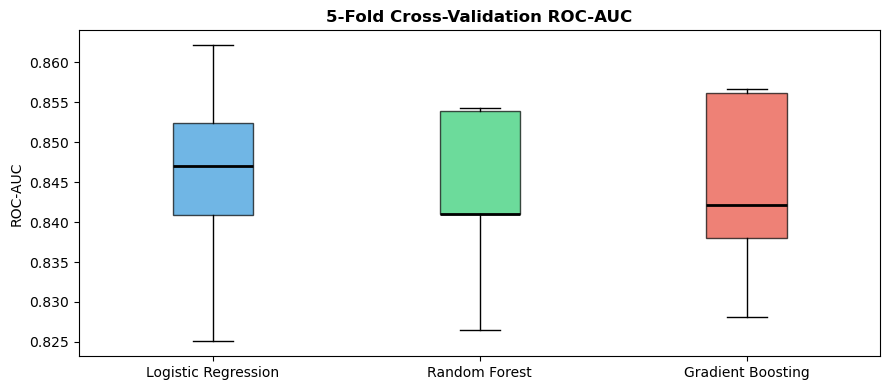

In [3]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=42, class_weight="balanced", n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, random_state=42)
}
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
 
print(f"{"Model":<25}  AUC (ort.)  Std")
print("-" * 42)
for name, model in models.items():
    X_use = X_train_sc if name == "Logistic Regression" else X_train
    scores = cross_val_score(
        model, X_use, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25}  {scores.mean():.4f}     ±{scores.std():.4f}")
 
# Boxplot
fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot(
    [cv_results[m] for m in models],
    labels=models.keys(), patch_artist=True,
    medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"],
                        ["#3498DB", "#2ECC71", "#E74C3C"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("5-Fold Cross-Validation ROC-AUC", fontweight="bold")
ax.set_ylabel("ROC-AUC")
plt.tight_layout()
plt.savefig("../outputs/figures/06_cv_comparison.png")
plt.show()

In [4]:
trained = {}
 
for name, model in models.items():
    X_tr = X_train_sc if name == "Logistic Regression" else X_train
    X_te = X_test_sc  if name == "Logistic Regression" else X_test
    model.fit(X_tr, y_train)
    trained[name] = model
 
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
 
    print(f"\n{"="*55}")
    print(f"  {name}  |  Test AUC: {auc:.4f}")
    print("="*55)
    print(classification_report(
        y_test, y_pred,
        target_names=["Kalmış", "Ayrılmış"]))



  Logistic Regression  |  Test AUC: 0.8413
              precision    recall  f1-score   support

      Kalmış       0.90      0.72      0.80      1035
    Ayrılmış       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest  |  Test AUC: 0.8403
              precision    recall  f1-score   support

      Kalmış       0.89      0.78      0.83      1035
    Ayrılmış       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409


  Gradient Boosting  |  Test AUC: 0.8419
              precision    recall  f1-score   support

      Kalmış       0.84      0.90      0.87      1035
    Ayrılmış       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   m

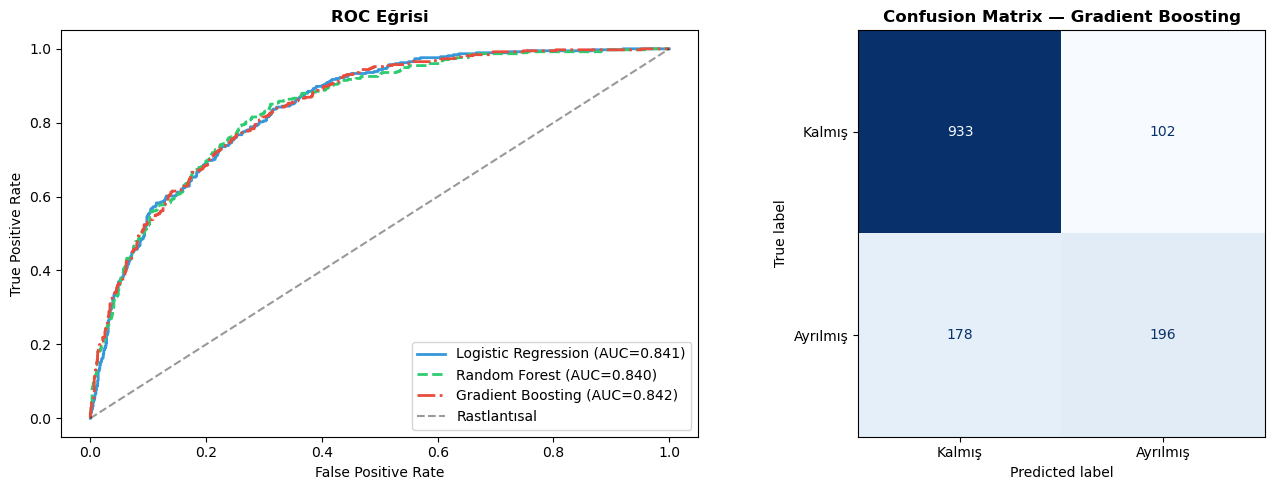

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
palette     = ["#3498DB", "#2ECC71", "#E74C3C"]
line_styles = ["-", "--", "-."]
 
for (name, model), ls, color in zip(
        trained.items(), line_styles, palette):
    X_te  = X_test_sc if name == "Logistic Regression" else X_test
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, ls=ls, color=color, lw=2,
                 label=f"{name} (AUC={auc:.3f})")
 
axes[0].plot([0,1],[0,1], "k--", alpha=0.4, label="Rastlantısal")
axes[0].set_title("ROC Eğrisi", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
 
# En iyi model: Gradient Boosting
y_pred_best = trained["Gradient Boosting"].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(
    cm, display_labels=["Kalmış", "Ayrılmış"]
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix — Gradient Boosting",
                  fontweight="bold")
 
plt.tight_layout()
plt.savefig("../outputs/figures/07_roc_and_cm.png")
plt.show()

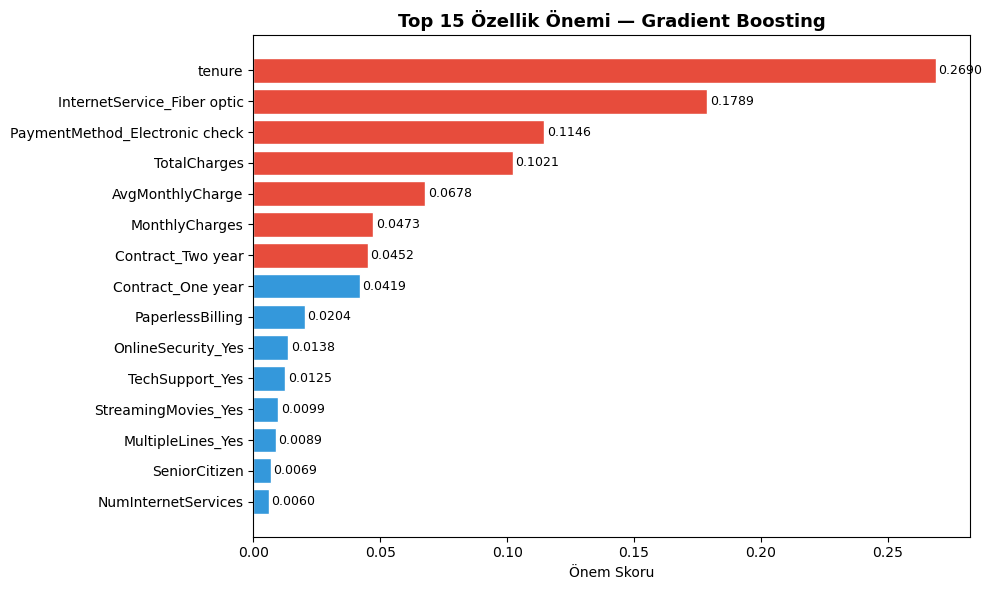

En önemli 5 değişken:
  1. tenure: 0.2690
  2. InternetService_Fiber optic: 0.1789
  3. PaymentMethod_Electronic check: 0.1146
  4. TotalCharges: 0.1021
  5. AvgMonthlyCharge: 0.0678


In [6]:
gb = trained["Gradient Boosting"]
fi = pd.Series(gb.feature_importances_, index=X_train.columns)
fi_top = fi.nlargest(15)
 
fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ["#E74C3C" if v > fi_top.median() else "#3498DB"
             for v in fi_top.values]
 
bars = ax.barh(
    fi_top.index[::-1], fi_top.values[::-1],
    color=colors_fi[::-1], edgecolor="white")
for bar, val in zip(bars, fi_top.values[::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
 
ax.set_title("Top 15 Özellik Önemi — Gradient Boosting",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Önem Skoru")
plt.tight_layout()
plt.savefig("../outputs/figures/08_feature_importance.png")
plt.show()
 
print("En önemli 5 değişken:")
for i, (feat, score) in enumerate(fi_top.head(5).items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")

In [7]:
import pickle
from sklearn.metrics import accuracy_score, f1_score
 
# Modeli kaydet
with open("../outputs/gb_churn_model.pkl", "wb") as f:
    pickle.dump(trained["Gradient Boosting"], f)
print("Model kaydedildi: outputs/gb_churn_model.pkl")
 
# Karşılaştırma tablosu
summary = []
for name, model in trained.items():
    X_te  = X_test_sc if name == "Logistic Regression" else X_test
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)
    summary.append({
        "Model"   : name,
        "AUC"     : round(roc_auc_score(y_test, y_prob), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4)
    })
 
print("\nModel Karşılaştırma:")
print(pd.DataFrame(summary).to_string(index=False))

Model kaydedildi: outputs/gb_churn_model.pkl

Model Karşılaştırma:
              Model    AUC  F1-Score  Accuracy
Logistic Regression 0.8413    0.6149    0.7395
      Random Forest 0.8403    0.6228    0.7679
  Gradient Boosting 0.8419    0.5833    0.8013
